# Food Weight Estimation Pipeline
**SAM3 → Coin Scale → YOLO12 → PCA → LangGraph + Gemini**

Place an RS10 coin (2.7 cm diameter) flat on the thali rim before photographing.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp /content/drive/MyDrive/yolo/best_convnextv2_tiny.pt /content/

In [ ]:
!cp /content/drive/MyDrive/yolo/photo_6210513029619715654_y.jpg /content/

In [ ]:
# ── HuggingFace token ────────────────────────────────────────────
import os
from google.colab import userdata

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

In [ ]:
# ── verify torch + CUDA ──────────────────────────────────────────
import torch
import torchvision

print("PyTorch     :", torch.__version__)
print("Torchvision :", torchvision.__version__)
print("CUDA        :", torch.cuda.is_available())

PyTorch     : 2.10.0+cu128
Torchvision : 0.25.0+cu128
CUDA        : True


In [ ]:
# ── install SAM3 ─────────────────────────────────────────────────
!git clone https://github.com/facebookresearch/sam3.git
%cd sam3
!pip install -e ".[notebooks]"
%cd /content

Cloning into 'sam3'...
remote: Enumerating objects: 974, done.
remote: Counting objects: 100% (344/344), done.
remote: Compressing objects: 100% (185/185), done.
remote: Total 974 (delta 201), reused 175 (delta 159), pack-reused 630 (from 1)
Receiving objects: 100% (974/974), 59.65 MiB | 22.86 MiB/s, done.
Resolving deltas: 100% (361/361), done.
/content/sam3
Obtaining file:///content/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1

/content


In [ ]:
# ── install dependencies (Forcing NumPy 1.x to protect SAM3) ─────
!pip install -q supervision jupyter_bbox_widget timm albumentations "numpy<2.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 MB 13.9 MB/s eta 0:00:00


In [ ]:
# ── GPU setup (FIXED — no global autocast leak) ──────────────────
import torch

if torch.cuda.is_available():
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
# autocast is applied per inference block below — not globally

In [ ]:
# ── load SAM3 model ──────────────────────────────────────────────
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

model     = build_sam3_image_model(
    bpe_path="/content/sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz"
)
processor = Sam3Processor(model, confidence_threshold=0.3)
print("SAM3 loaded")

config.json: 0.00B [00:00, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

SAM3 loaded


In [ ]:
# ── from_sam helper ──────────────────────────────────────────────
import torch
import numpy as np
import supervision as sv

def from_sam(sam_result: dict) -> sv.Detections:
    xyxy       = sam_result["boxes"].to(torch.float32).cpu().numpy()
    confidence = sam_result["scores"].to(torch.float32).cpu().numpy()
    mask       = sam_result["masks"].to(torch.bool)
    mask       = mask.squeeze(1).cpu().numpy()   # safe for all shapes
    return sv.Detections(xyxy=xyxy, confidence=confidence, mask=mask)

In [ ]:
# ── annotate helper + color palette ─────────────────────────────
import supervision as sv
from PIL import Image
from typing import Optional

COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

def annotate(
    image: Image.Image,
    detections: sv.Detections,
    label: Optional[str] = None
) -> Image.Image:
    mask_ann  = sv.MaskAnnotator(color=COLOR, color_lookup=sv.ColorLookup.INDEX, opacity=0.6)
    box_ann   = sv.BoxAnnotator(color=COLOR, color_lookup=sv.ColorLookup.INDEX, thickness=1)
    label_ann = sv.LabelAnnotator(
        color=COLOR, color_lookup=sv.ColorLookup.INDEX,
        text_scale=0.4, text_padding=5,
        text_color=sv.Color.BLACK, text_thickness=1
    )
    out = image.copy()
    out = mask_ann.annotate(out, detections)
    out = box_ann.annotate(out, detections)
    if label:
        labels = [f"{label} {c:.2f}" for c in detections.confidence]
        out = label_ann.annotate(out, detections, labels)
    return out

In [ ]:
# ── merge_detections ─────────────────────────────────────────────
import numpy as np
import supervision as sv
from typing import List, Tuple

def mask_iou(m1: np.ndarray, m2: np.ndarray) -> float:
    inter = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()
    return float(inter / union) if union > 0 else 0.0

def mask_containment(m_small: np.ndarray, m_large: np.ndarray) -> float:
    inter = np.logical_and(m_small, m_large).sum()
    area  = m_small.sum()
    return float(inter / area) if area > 0 else 0.0

def merge_detections(
    det_p1: sv.Detections,
    det_p2: sv.Detections,
    det_p3: sv.Detections,
    prompt_labels: List[str],
    iou_threshold: float = 0.30,
    containment_threshold: float = 0.25,
) -> Tuple[sv.Detections, List[str]]:

    masks, xyxys, confs, tags = [], [], [], []
    CONTAINER_TAGS = {0, 1}
    FOOD_ONLY_TAGS = {2}
    tag_name = {i: lbl for i, lbl in enumerate(prompt_labels)}

    for src_idx, dets in enumerate([det_p1, det_p2, det_p3]):
        if dets is None or len(dets) == 0:
            continue
        for i in range(len(dets)):
            masks.append(dets.mask[i])
            xyxys.append(dets.xyxy[i])
            confs.append(float(dets.confidence[i]))
            tags.append(src_idx)

    n = len(masks)
    if n == 0:
        return sv.Detections.empty(), []

    iou_mat = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        for j in range(i + 1, n):
            v = mask_iou(masks[i], masks[j])
            iou_mat[i, j] = iou_mat[j, i] = v

    visited = [False] * n
    groups  = []
    for start in range(n):
        if visited[start]:
            continue
        group, queue = [], [start]
        visited[start] = True
        while queue:
            cur = queue.pop()
            group.append(cur)
            for nb in range(n):
                if not visited[nb] and iou_mat[cur, nb] >= iou_threshold:
                    visited[nb] = True
                    queue.append(nb)
        groups.append(group)

    keep_indices = []
    for group in groups:
        containers = [idx for idx in group if tags[idx] in CONTAINER_TAGS]
        food_only  = [idx for idx in group if tags[idx] in FOOD_ONLY_TAGS]
        if containers:
            keep_indices.append(max(containers, key=lambda idx: confs[idx]))
        elif food_only:
            keep_indices.append(max(food_only,  key=lambda idx: confs[idx]))

    container_kept = [masks[i] for i in keep_indices if tags[i] in CONTAINER_TAGS]
    final_indices  = []
    for i in keep_indices:
        if tags[i] in FOOD_ONLY_TAGS:
            if any(mask_containment(masks[i], c) >= containment_threshold
                   for c in container_kept):
                print(f"  Dropped food-inside-container (conf={confs[i]:.2f})")
                continue
        final_indices.append(i)

    if not final_indices:
        return sv.Detections.empty(), []

    return sv.Detections(
        xyxy       = np.array([xyxys[i] for i in final_indices]),
        confidence = np.array([confs[i]  for i in final_indices]),
        mask       = np.array([masks[i]  for i in final_indices]),
    ), [tag_name.get(tags[i], "?") for i in final_indices]

In [ ]:
# ════════════════════════════════════════════════════════════════
# CONFIG — only edit this cell
# ════════════════════════════════════════════════════════════════
import os
from google.colab import userdata

IMAGE_PATH  = "/content/photo_6210513029619715654_y.jpg"   # ← change per run
CKPT_PATH   = "/content/best_convnextv2_tiny.pt"          # ← your trained YOLOv12 weights
CONVNEXT_CONF_THRESH = 0.8


# SAM3 thresholds
CONF_THRESH      = 0.60
IOU_THRESH       = 0.40
CONT_THRESH      = 0.25

# Coin — RBI RS10 spec
COIN_DIAMETER_CM = 2.7
COIN_CONF_THRESH = 0.50

# YOLO
YOLO_CONF_THRESH = 0.35

SAVE_DIR = "/content/pipeline_out"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Config OK")

Config OK


Food raw  → P1:0  P2:0  P3:1
Coin dets → 1
Food after merge → 1 segments


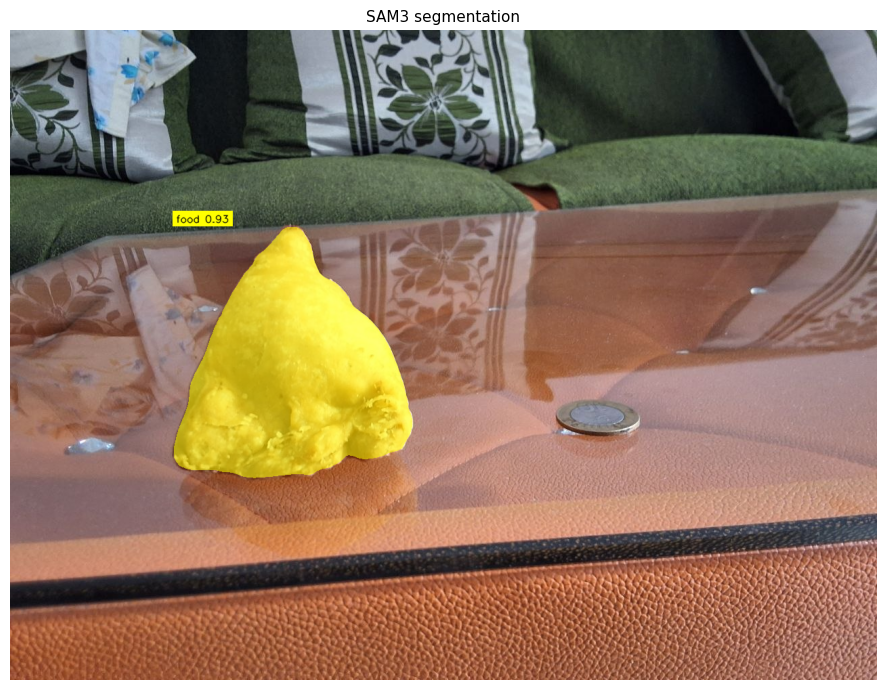

In [ ]:
# ── SAM3 segmentation — food + coin (separate) ──────────────────
import copy
import numpy as np
import supervision as sv
from PIL import Image

PROMPT_1    = "food and its bowl"
PROMPT_2    = "food and only its bowl"
PROMPT_3    = "food"
PROMPT_COIN = "coin"   # isolated — never enters food merge

image           = Image.open(IMAGE_PATH).convert("RGB")
inference_state = processor.set_image(image)

def get_dets(prompt: str, conf: float = CONF_THRESH) -> sv.Detections:
    state = processor.set_text_prompt(
        state=copy.deepcopy(inference_state), prompt=prompt
    )
    dets = from_sam(sam_result=state)
    return dets[dets.confidence > conf]

det1      = get_dets(PROMPT_1)
det2      = get_dets(PROMPT_2)
det3      = get_dets(PROMPT_3)
coin_dets = get_dets(PROMPT_COIN, conf=COIN_CONF_THRESH)

print(f"Food raw  → P1:{len(det1)}  P2:{len(det2)}  P3:{len(det3)}")
print(f"Coin dets → {len(coin_dets)}")

food_dets, food_labels = merge_detections(
    det1, det2, det3,
    prompt_labels=[PROMPT_1, PROMPT_2, PROMPT_3],
    iou_threshold=IOU_THRESH,
    containment_threshold=CONT_THRESH,
)
print(f"Food after merge → {len(food_dets)} segments")

# quick overview
import matplotlib.pyplot as plt
overview = image.copy()
overview = sv.MaskAnnotator(color=COLOR, color_lookup=sv.ColorLookup.INDEX,
                            opacity=0.55).annotate(overview, food_dets)
overview = sv.LabelAnnotator(
    color=COLOR, color_lookup=sv.ColorLookup.INDEX,
    text_scale=0.5, text_padding=5, text_color=sv.Color.BLACK,
).annotate(overview, food_dets,
           labels=[f"{l} {c:.2f}" for l, c in
                   zip(food_labels, food_dets.confidence)])
plt.figure(figsize=(10, 7))
plt.imshow(overview); plt.axis("off")
plt.title("SAM3 segmentation", fontsize=11); plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/overview.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# ── PCA helpers ──────────────────────────────────────────────────
from sklearn.decomposition import PCA as skPCA
import numpy as np

def pca_geometry(mask: np.ndarray):
    """PCA on mask (x,y) pixel coords → ellipse axes + rotation angle."""
    ys, xs    = np.where(mask)
    coords    = np.stack([xs, ys], axis=1).astype(np.float32)
    center    = coords.mean(axis=0)
    pca       = skPCA(n_components=2)
    pca.fit(coords)
    stds      = np.sqrt(pca.explained_variance_)
    major_px  = 4 * stds[0]   # 4σ  ≈ 95% of pixels
    minor_px  = 4 * stds[1]
    pc1       = pca.components_[0]
    angle_deg = np.degrees(np.arctan2(pc1[1], pc1[0]))
    return center, (major_px, minor_px), angle_deg, pca.components_

def estimate_height_px(mask: np.ndarray) -> float:
    """Proxy: shorter bbox side × empirical fill ratio for bowls."""
    ys, xs = np.where(mask)
    return float(min(ys.max()-ys.min(), xs.max()-xs.min())) * 0.35

print("PCA helpers ready")

PCA helpers ready


  Coin  major=125.4px  minor=52.6px  roundness=0.42  =>  46.457 px/cm


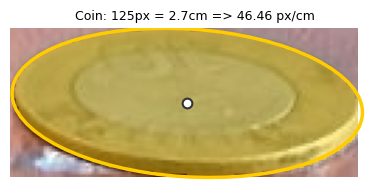

  Confirmed scale: 46.457 px/cm


In [ ]:
# ── coin → PIXELS_PER_CM ─────────────────────────────────────────
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import numpy as np

def extract_coin_scale(coin_dets, img_np) -> float:
    """
    Pick best-confidence coin detection.
    PCA major axis / 2.7cm = pixels_per_cm.
    Returns (pixels_per_cm, coin_mask) or (None, None).
    """
    if coin_dets is None or len(coin_dets) == 0:
        print("  WARNING: no coin detected.")
        return None, None

    best_idx  = int(np.argmax(coin_dets.confidence))
    coin_mask = coin_dets.mask[best_idx]
    coin_xyxy = coin_dets.xyxy[best_idx]

    _, (major_px, minor_px), _, _ = pca_geometry(coin_mask)

    ratio = minor_px / major_px if major_px > 0 else 0
    if ratio < 0.6:
        print(f"  WARNING: coin may be tilted (roundness={ratio:.2f}). "
              "Lay it flat for best accuracy.")

    px_per_cm = major_px / COIN_DIAMETER_CM
    print(f"  Coin  major={major_px:.1f}px  minor={minor_px:.1f}px  "
          f"roundness={ratio:.2f}  =>  {px_per_cm:.3f} px/cm")

    # visualise
    x1, y1, x2, y2   = map(int, coin_xyxy)
    c_img             = img_np[y1:y2, x1:x2]
    c_mask            = coin_mask[y1:y2, x1:x2]
    c_ctr, (cm, cn), ca, _ = pca_geometry(c_mask)

    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(c_img)
    ov = np.zeros((*c_mask.shape, 4), dtype=np.float32)
    ov[c_mask] = [1.0, 0.85, 0.0, 0.4]
    ax.imshow(ov)
    ax.add_patch(Ellipse(xy=c_ctr, width=cm, height=cn, angle=ca,
                         edgecolor="#ffcc00", facecolor="none", linewidth=2.5))
    ax.plot(*c_ctr, "o", color="white", markersize=7,
            markeredgecolor="#333", markeredgewidth=1.5)
    ax.set_title(f"Coin: {major_px:.0f}px = {COIN_DIAMETER_CM}cm "
                 f"=> {px_per_cm:.2f} px/cm", fontsize=9)
    ax.axis("off")
    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/coin_scale.png", dpi=120, bbox_inches="tight")
    plt.show(); plt.close()

    return px_per_cm, coin_mask


img_np = np.array(image)
PIXELS_PER_CM, _coin_mask = extract_coin_scale(coin_dets, img_np)

if PIXELS_PER_CM is None:
    PIXELS_PER_CM = 18.0   # fallback — measure manually
    print(f"  Using fallback: {PIXELS_PER_CM} px/cm")
else:
    print(f"  Confirmed scale: {PIXELS_PER_CM:.3f} px/cm")

In [ ]:
# ── ConvNeXtV2 Tiny classification ───────────────────────────────
import torch
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- load checkpoint ---
print(f"Loading ConvNeXtV2 from {CKPT_PATH}...")
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)

class_to_idx = ckpt["class_to_idx"]
idx_to_class = {v: k for k, v in class_to_idx.items()}
NUM_CLASSES  = ckpt["cfg"]["num_classes"]
IMG_SIZE     = ckpt["cfg"]["img_size"]
MODEL_NAME   = ckpt["cfg"]["model_name"]

# --- rebuild model ---
cls_model = timm.create_model(
    MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES, drop_rate=0.0
)
cls_model.load_state_dict(ckpt["model_state"])
cls_model = cls_model.to(DEVICE, memory_format=torch.channels_last)
cls_model.eval()
print(f"ConvNeXtV2 loaded  —  {NUM_CLASSES} classes: {list(class_to_idx.keys())}")

# --- inference transform ---
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

inference_transform = A.Compose([
    A.Resize(height=int(IMG_SIZE * 1.14), width=int(IMG_SIZE * 1.14)),
    A.CenterCrop(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

def classify_crop(crop_rgb: np.ndarray, conf_thresh: float = CONVNEXT_CONF_THRESH):
    """Classify an RGB numpy crop with ConvNeXtV2 Tiny."""
    tensor = inference_transform(image=crop_rgb)["image"].unsqueeze(0)
    tensor = tensor.to(DEVICE, memory_format=torch.channels_last)

    with torch.no_grad(), torch.amp.autocast("cuda"):
        logits = cls_model(tensor)
        probs = torch.softmax(logits, dim=1)[0]

    top_prob, top_idx = probs.max(0)
    conf = top_prob.item()

    if conf < conf_thresh:
        return None, conf
    return idx_to_class[top_idx.item()], conf

# --- classify every SAM segment ---
convnext_results = []
print(f"\n{'#':<4} {'SAM label':<28} {'Food class':<22} {'conf':<8} status")
print("─" * 68)

for i, (mask, xyxy, label) in enumerate(zip(food_dets.mask, food_dets.xyxy, food_labels)):
    x1, y1, x2, y2 = map(int, xyxy)
    crop_rgb       = img_np[y1:y2, x1:x2]

    food_class, conf = classify_crop(crop_rgb)

    print(f"{i:<4} {label:<28} {str(food_class):<22} {conf:<8.2f} "
          f"{'KEEP' if food_class else 'DISCARD'}")

    if food_class:
        convnext_results.append({
            "seg_idx":    i,
            "sam_label":  label,
            "food_class": food_class,
            "cls_conf":   conf,
            "mask":       mask,
            "xyxy":       xyxy,
            "crop_img":   crop_rgb,
            "crop_mask":  mask[y1:y2, x1:x2],
        })

print(f"\nKept {len(convnext_results)} / {len(food_dets)} after ConvNeXtV2 filter")

Loading ConvNeXtV2 from /content/best_convnextv2_tiny.pt...
ConvNeXtV2 loaded  —  80 classes: ['aloo gobi', 'aloo methi', 'aloo mutter', 'aloo paratha', 'amritsari kulcha', 'anda curry', 'balushahi', 'banana chips', 'besan laddu', 'bhindi masala', 'biryani', 'boondi laddu', 'chaas', 'chana masala', 'chapati', 'chicken pizza', 'chicken wings', 'chikki', 'chivda', 'chole bhature', 'dabeli', 'dal khichdi', 'dhokla', 'falooda', 'fish curry', 'gajar ka halwa', 'garlic bread', 'garlic naan', 'ghevar', 'grilled sandwich', 'gujhia', 'gulab jamun', 'hara bhara kabab', 'idiyappam', 'idli', 'jalebi', 'kaju katli', 'khakhra', 'kheer', 'kulfi', 'margherita pizza', 'masala dosa', 'masala papad', 'medu vada', 'misal pav', 'modak', 'moong dal halwa', 'murukku', 'mysore pak', 'navratan korma', 'neer dosa', 'onion pakoda', 'palak paneer', 'paneer masala', 'paneer pizza', 'pani puri', 'paniyaram', 'papdi chaat', 'patrode', 'pav bhaji', 'pepperoni pizza', 'phirni', 'poha', 'pongal', 'puri bhaji', 'rajma c

#    Food                   d(cm)     w(cm)     h(cm)
───────────────────────────────────────────────────────
0    samosa                 7.60      7.03      2.64


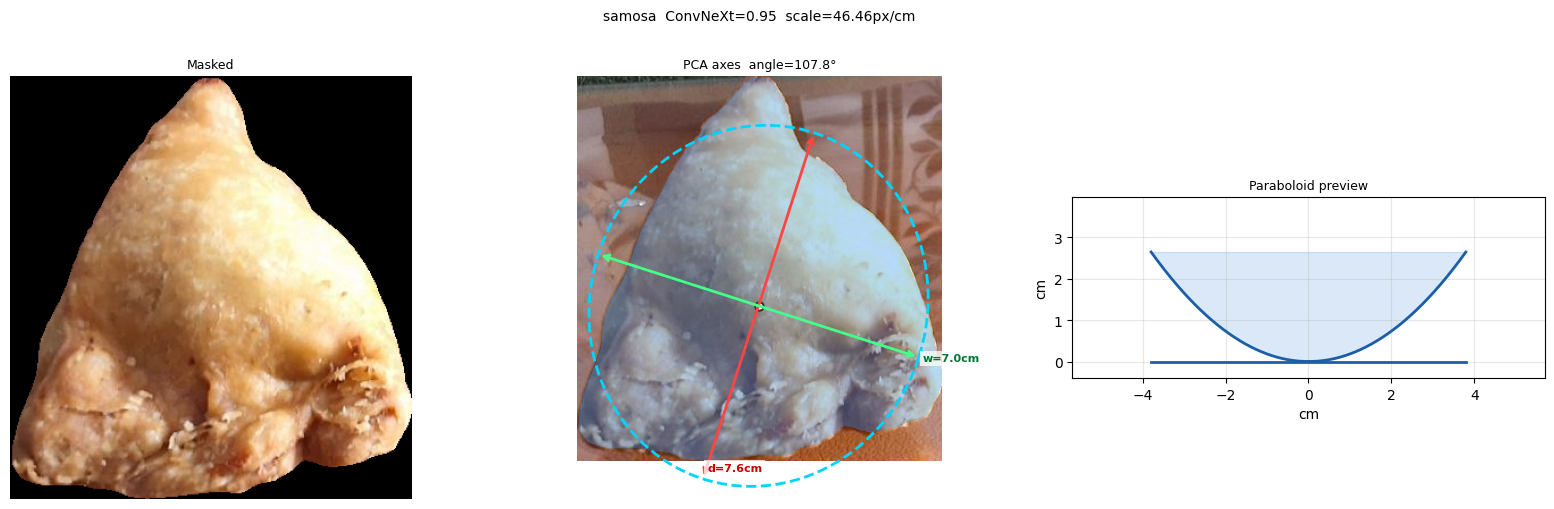


1 items ready for Gemini


In [ ]:
# ── PCA geometry on confirmed segments ───────────────────────────
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import numpy as np

pca_data = []

print(f"{'#':<4} {'Food':<22} {'d(cm)':<9} {'w(cm)':<9} {'h(cm)'}")
print("─" * 55)

for item in convnext_results:
    crop_mask = item["crop_mask"]
    crop_img  = item["crop_img"]

    if crop_mask.sum() < 50:
        print(f"  SKIP {item['food_class']} — too few pixels")
        continue

    center, (major_px, minor_px), angle_deg, eigenvecs = pca_geometry(crop_mask)
    height_px   = estimate_height_px(crop_mask)
    diameter_cm = major_px  / PIXELS_PER_CM
    minor_cm    = minor_px  / PIXELS_PER_CM
    height_cm   = height_px / PIXELS_PER_CM
    radius_cm   = diameter_cm / 2.0

    print(f"{item['seg_idx']:<4} {item['food_class']:<22} "
          f"{diameter_cm:<9.2f} {minor_cm:<9.2f} {height_cm:.2f}")

    # ── 3-panel plot ─────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(
        f"{item['food_class']}  ConvNeXt={item['cls_conf']:.2f}  "  # <-- FIXED HERE
        f"scale={PIXELS_PER_CM:.2f}px/cm",
        fontsize=10, y=1.01
    )

    # panel 1 — masked
    masked = crop_img.copy(); masked[~crop_mask] = 0
    axes[0].imshow(masked); axes[0].set_title("Masked", fontsize=9)
    axes[0].axis("off")

    # panel 2 — PCA ellipse
    axes[1].imshow(crop_img)
    ov = np.zeros((*crop_mask.shape, 4), dtype=np.float32)
    ov[crop_mask] = [0.2, 0.6, 1.0, 0.35]
    axes[1].imshow(ov)
    cx, cy = center
    axes[1].add_patch(Ellipse(
        xy=(cx, cy), width=major_px, height=minor_px, angle=angle_deg,
        edgecolor="#00d4ff", facecolor="none", linewidth=2, linestyle="--"
    ))
    pc1 = eigenvecs[0]; hl = major_px / 2
    axes[1].annotate("",
        xy=(cx+pc1[0]*hl, cy+pc1[1]*hl),
        xytext=(cx-pc1[0]*hl, cy-pc1[1]*hl),
        arrowprops=dict(arrowstyle="<->", color="#ff4444", lw=2)
    )
    axes[1].text(cx+pc1[0]*hl+4, cy+pc1[1]*hl-8,
        f"d={diameter_cm:.1f}cm", color="#cc0000", fontsize=8,
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.75, pad=2, edgecolor="none"))
    pc2 = eigenvecs[1]; ml = minor_px / 2
    axes[1].annotate("",
        xy=(cx+pc2[0]*ml, cy+pc2[1]*ml),
        xytext=(cx-pc2[0]*ml, cy-pc2[1]*ml),
        arrowprops=dict(arrowstyle="<->", color="#44ff88", lw=2)
    )
    axes[1].text(cx+pc2[0]*ml+4, cy+pc2[1]*ml+4,
        f"w={minor_cm:.1f}cm", color="#007733", fontsize=8,
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.75, pad=2, edgecolor="none"))
    axes[1].plot(cx, cy, "o", color="white", markersize=6,
                 markeredgecolor="#333", markeredgewidth=1.5)
    axes[1].set_title(f"PCA axes  angle={angle_deg:.1f}°", fontsize=9)
    axes[1].axis("off")

    # panel 3 — paraboloid preview
    ax3 = axes[2]
    ax3.set_aspect("equal")
    ax3.set_xlim(-radius_cm*1.5, radius_cm*1.5)
    ax3.set_ylim(-0.4, max(height_cm*1.5, 1.0))
    y_v = np.linspace(0, height_cm, 300)
    x_r = radius_cm * np.sqrt(np.clip(y_v / max(height_cm, 0.01), 0, None))
    ax3.fill_betweenx(y_v, -x_r, x_r, color="#4a90d9", alpha=0.2)
    ax3.plot( x_r, y_v, color="#1a5fa8", lw=2)
    ax3.plot(-x_r, y_v, color="#1a5fa8", lw=2)
    ax3.plot([-radius_cm, radius_cm], [0, 0], color="#1a5fa8", lw=2)
    ax3.set_title("Paraboloid preview", fontsize=9)
    ax3.set_xlabel("cm"); ax3.set_ylabel("cm")
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        f"{SAVE_DIR}/pca_{item['seg_idx']:02d}_{item['food_class']}.png",
        dpi=130, bbox_inches="tight"
    )
    plt.show(); plt.close()

    pca_data.append({
        "seg_idx":     item["seg_idx"],
        "sam_label":   item["sam_label"],
        "food_class":  item["food_class"],
        "cls_conf":    item["cls_conf"],   # <-- FIXED HERE
        "diameter_cm": round(diameter_cm, 2),
        "minor_cm":    round(minor_cm, 2),
        "height_cm":   round(height_cm, 2),
        "radius_cm":   round(radius_cm, 2),
        "crop_img":    crop_img,
    })

print(f"\n{len(pca_data)} items ready for Gemini")

In [ ]:
import math
import statistics

def get_inputs():
    print("=" * 55)
    print("        BOWL VOLUME & WEIGHT CALCULATOR")
    print("=" * 55)
    height   = 7.60
    diameter = 7
    density  = 0.9
    radius   = diameter / 2
    print()
    return height, radius, density


def volume_paraboloid(h, r):
    """V = (π × r² × h) / 2"""
    return (math.pi * r**2 * h) / 2


def volume_half_sphere(h, r):
    """V = (2/3) × π × r³"""
    return (2 / 3) * math.pi * r**3


def volume_spherical_cap(h, r):
    """V = (π × h / 6) × (3r² + h²)"""
    return (math.pi * h / 6) * (3 * r**2 + h**2)


def volume_flat_bottom_cylinder(h, r):
    """V = π × r² × h"""
    return math.pi * r**2 * h


def calc_weight(volume, density):
    """Weight = Volume × Density"""
    return volume * density


def print_result(name, formula_str, volume, weight):
    print(f"  {'Shape':<32} {name}")
    print(f"  {'Formula (Volume)':<32} {formula_str}")
    print(f"  {'Volume':<32} {volume:.4f} cubic units")
    print(f"  {'Weight (V × density)':<32} {weight:.4f} kg")
    print("-" * 55)


def print_stats(label, values):
    """Print mean and median for a list of values."""
    mean   = statistics.mean(values)
    median = statistics.median(values)
    print(f"  {label:<33} Mean: {mean:>10.4f}   Median: {median:>10.4f}")


def main():
    h, r, rho = get_inputs()

    print(f"  Inputs → Height: {h}, Radius: {r}, Diameter: {r*2}, Density: {rho}")
    print("=" * 55)
    print()

    # 1. Paraboloid
    v1 = volume_paraboloid(h, r)
    w1 = calc_weight(v1, rho)
    print("1️⃣  PARABOLOID")
    print_result("Paraboloid Bowl", "V = (π × r² × h) / 2", v1, w1)

    # 2. Perfect Half-Sphere
    v2 = volume_half_sphere(h, r)
    w2 = calc_weight(v2, rho)
    print("2️⃣  PERFECT HALF-SPHERE")
    print_result("Hemispherical Bowl", "V = (2/3) × π × r³", v2, w2)

    # 3. Spherical Cap
    v3 = volume_spherical_cap(h, r)
    w3 = calc_weight(v3, rho)
    print("3️⃣  SHALLOW OR DEEP CURVE (Spherical Cap)")
    print_result("Spherical Cap Bowl", "V = (π×h/6) × (3r² + h²)", v3, w3)

    # 4. Flat-Bottomed Cylinder
    v4 = volume_flat_bottom_cylinder(h, r)
    w4 = calc_weight(v4, rho)
    print("4️⃣  FLAT-BOTTOMED BOWL WITH STRAIGHT SIDES")
    print_result("Cylindrical Bowl", "V = π × r² × h", v4, w4)

    # --- Collect all volumes and weights ---
    volumes = [v1, v2, v3, v4]
    weights = [w1, w2, w3, w4]

    results = [
        ("Paraboloid",                   v1, w1),
        ("Perfect Half-Sphere",          v2, w2),
        ("Spherical Cap (Shallow/Deep)", v3, w3),
        ("Flat-Bottom + Straight Sides", v4, w4),
    ]

    # --- Summary Table ---
    print("\n📊 SUMMARY TABLE")
    print("=" * 55)
    print(f"  {'Shape':<33} {'Volume':>8}   {'Weight':>8}")
    print("-" * 55)
    for name, vol, wt in results:
        print(f"  {name:<33} {vol:>8.4f}   {wt:>8.4f} kg")
    print("=" * 55)

    # --- Mean & Median ---
    mean_vol   = statistics.mean(volumes)
    median_vol = statistics.median(volumes)
    mean_wt    = statistics.mean(weights)
    median_wt  = statistics.median(weights)

    print("\n📐 STATISTICAL ANALYSIS (across all 4 shapes)")
    print("=" * 55)
    print(f"  {'Metric':<20} {'Volume':>12}   {'Weight':>12}")
    print("-" * 55)
    print(f"  {'Mean':<20} {mean_vol:>12.4f}   {mean_wt:>12.4f} kg")
    print(f"  {'Median':<20} {median_vol:>12.4f}   {median_wt:>12.4f} kg")
    print(f"  {'Min':<20} {min(volumes):>12.4f}   {min(weights):>12.4f} kg")
    print(f"  {'Max':<20} {max(volumes):>12.4f}   {max(weights):>12.4f} kg")
    print(f"  {'Range (Max-Min)':<20} {max(volumes)-min(volumes):>12.4f}   {max(weights)-min(weights):>12.4f} kg")
    print("=" * 55)
    print(f"\n  Density used: {rho} kg/unit³   |   Weight = Volume × Density")
    print("=" * 55)


if __name__ == "__main__":
    main()

        BOWL VOLUME & WEIGHT CALCULATOR

  Inputs → Height: 7.6, Radius: 3.5, Diameter: 7.0, Density: 0.9

1️⃣  PARABOLOID
  Shape                            Paraboloid Bowl
  Formula (Volume)                 V = (π × r² × h) / 2
  Volume                           146.2411 cubic units
  Weight (V × density)             131.6170 kg
-------------------------------------------------------
2️⃣  PERFECT HALF-SPHERE
  Shape                            Hemispherical Bowl
  Formula (Volume)                 V = (2/3) × π × r³
  Volume                           89.7972 cubic units
  Weight (V × density)             80.8175 kg
-------------------------------------------------------
3️⃣  SHALLOW OR DEEP CURVE (Spherical Cap)
  Shape                            Spherical Cap Bowl
  Formula (Volume)                 V = (π×h/6) × (3r² + h²)
  Volume                           376.0884 cubic units
  Weight (V × density)             338.4796 kg
-------------------------------------------------------
4️⃣  

In [ ]:
import torch
import cv2
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

# --- 1. SETUP ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CKPT_PATH = '/content/best_convnextv2_tiny.pt'

# We use weights_only=False because we saved dictionaries inside the checkpoint
print(f"Loading model from {CKPT_PATH}...")
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)

# --- 2. EXTRACT SAVED CONTEXT ---
# Pulling your dynamic variables straight from the checkpoint
class_to_idx = ckpt['class_to_idx']
idx_to_class = {v: k for k, v in class_to_idx.items()}  # Reverse it for inference
NUM_CLASSES  = ckpt['cfg']['num_classes']
IMG_SIZE     = ckpt['cfg']['img_size']
MODEL_NAME   = ckpt['cfg']['model_name']

# --- 3. REBUILD MODEL ---
model = timm.create_model(
    MODEL_NAME,
    pretrained=False,
    num_classes=NUM_CLASSES,
    drop_rate=0.0 # No dropout during inference
)
model.load_state_dict(ckpt['model_state'])
# Optimize layout for fast inference
model = model.to(DEVICE, memory_format=torch.channels_last)
model.eval()

# --- 4. REBUILD TRANSFORMS ---
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

inference_transform = A.Compose([
    A.Resize(height=int(IMG_SIZE * 1.14), width=int(IMG_SIZE * 1.14)),
    A.CenterCrop(height=IMG_SIZE, width=IMG_SIZE),
    A.Normalize(mean=MEAN, std=STD),
    ToTensorV2(),
])

# --- 5. PREDICTION FUNCTION ---
def predict_food(image_path: str, topk: int = 3):
    """Reads an image, passes it to ConvNeXtV2, and returns top K predictions."""

    # Read and convert image (BGR to RGB)
    img = cv2.imread(image_path)
    if img is None:
        return "Error: Image not found or corrupted."
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Apply transforms and add batch dimension [1, 3, 224, 224]
    tensor = inference_transform(image=img)['image'].unsqueeze(0)
    tensor = tensor.to(DEVICE, memory_format=torch.channels_last)

    # Run Inference
    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            logits = model(tensor)

        # Convert raw logits to percentages
        probs = torch.softmax(logits, dim=1)[0]
        top_probs, top_indices = probs.topk(topk)

    # Format results
    results = []
    for p, idx in zip(top_probs, top_indices):
        class_name = idx_to_class[idx.item()]
        confidence = p.item() * 100
        results.append((class_name, confidence))

    return results

# --- 6. TEST IT OUT ---
# Replace this string with a path to any test image!
test_image_path = '/content/photo_6210513029619715654_y.jpg'

print(f"\nAnalyzing: {test_image_path}")
predictions = predict_food(test_image_path, topk=3)

print("\n🍽️ Top Predictions:")
for rank, (food_class, confidence) in enumerate(predictions, 1):
    print(f"  {rank}. {food_class:<25} ({confidence:.2f}%)")

Loading model from /content/best_convnextv2_tiny.pt...

Analyzing: /content/photo_6210513029619715654_y.jpg

🍽️ Top Predictions:
  1. samosa                    (94.38%)
  2. garlic bread              (0.30%)
  3. grilled sandwich          (0.18%)
